In [ ]:
import os

# This prints everything inside your Google Drive
for folder in os.listdir('/content/drive/MyDrive'):
    print(folder)

Colab Notebooks
MST_6717.JPG
fsc.jpg
transcript.jpg
GAT.jpg
degree.jpg
matric (1).jpg
MST_6642.JPG
MST_6637.JPG
MST_7028.JPG
MST_7030.JPG
MST_7038.JPG
MST_7034.JPG
MST_7033.JPG
MST_6635.JPG
MST_7029.JPG
MST_6640.JPG
MST_7040.JPG
MST_6641.JPG
MST_6636.JPG
MST_7039.JPG
MST_7035.JPG
DUA PIC.jpg
ID Father.jpg
DUA ID.jpg
sl nust.jpg
E.pdf
helmet.v2i.coco.zip
yolov8_results
Copy of helmet.v2i.coco.zip


In [ ]:
# Replace 'segmentation_dataset' with whatever YOUR folder is named
for folder in os.listdir('/content/drive/MyDrive/yolov8_results'):
    print(folder)

custom_run


In [ ]:
import os

# List contents of custom_run to identify the correct path for images and masks
print(f"Contents of /content/drive/MyDrive/yolov8_results/custom_run/:")
for item in os.listdir('/content/drive/MyDrive/yolov8_results/custom_run'):
    print(item)

Contents of /content/drive/MyDrive/yolov8_results/custom_run/:
weights
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
BoxPR_curve.png
BoxF1_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix_normalized.png
confusion_matrix.png
results.csv
results.png


Using device: cuda
Train: 13 | Val: 4
Model parameters: 7,702,977
Epoch   1/30 | Train Loss: 0.6309 | Val Loss: 0.6903 | Val Acc: 0.5416
Epoch   5/30 | Train Loss: 0.4041 | Val Loss: 0.6696 | Val Acc: 0.5416
Epoch  10/30 | Train Loss: 0.3235 | Val Loss: 0.5318 | Val Acc: 0.8290
Epoch  15/30 | Train Loss: 0.3221 | Val Loss: 0.3759 | Val Acc: 0.8809
Epoch  20/30 | Train Loss: 0.2960 | Val Loss: 0.3360 | Val Acc: 0.8766
Epoch  25/30 | Train Loss: 0.2928 | Val Loss: 0.3259 | Val Acc: 0.8737
Epoch  30/30 | Train Loss: 0.2528 | Val Loss: 0.3256 | Val Acc: 0.8693
Model saved to /content/drive/MyDrive/unet_task2.pth


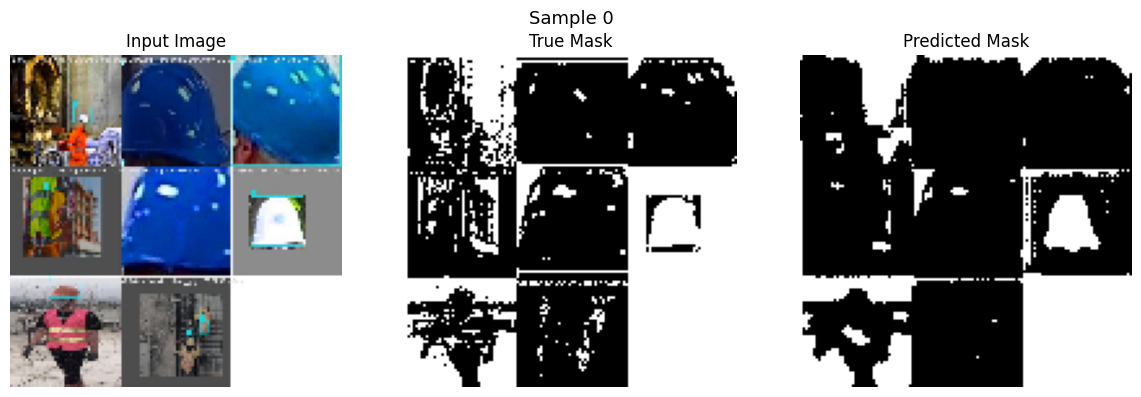

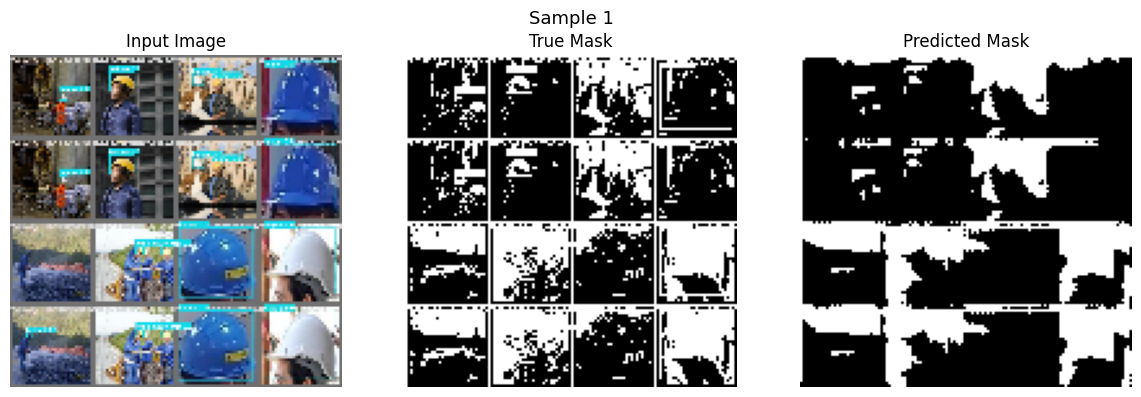

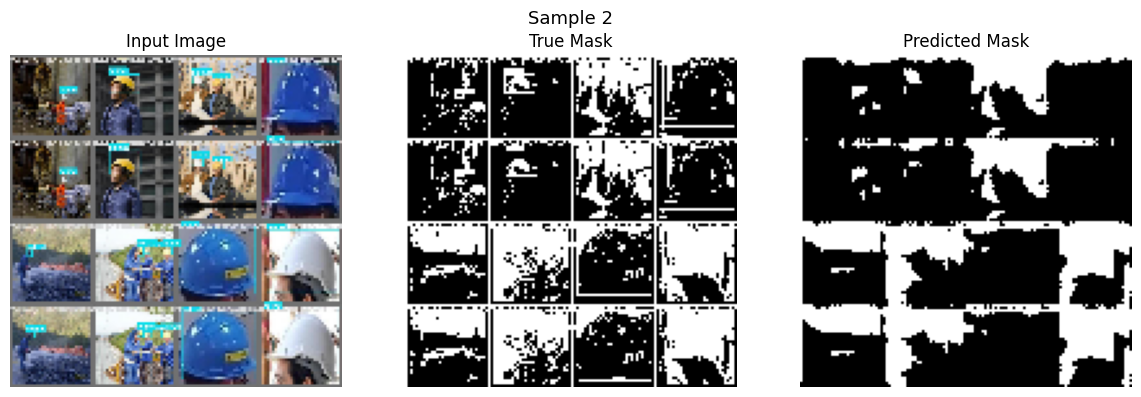

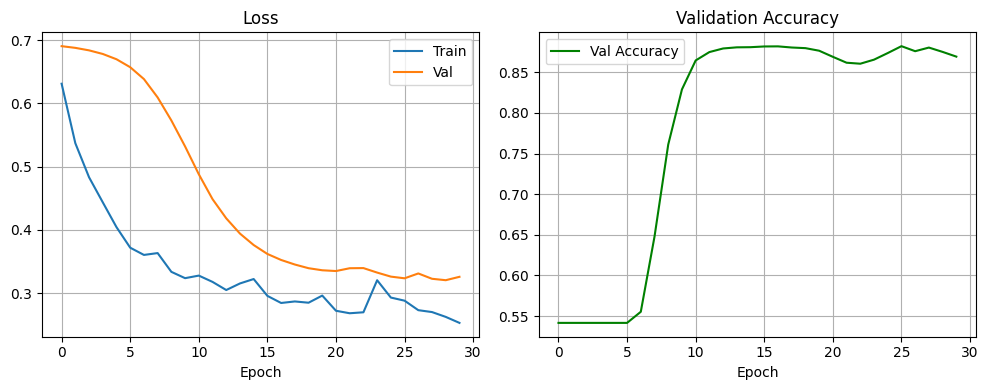

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms

# ---- GPU check ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ============================================================
# CHANGE 1: Set your Google Drive image/mask folder paths
# ============================================================
IMAGE_DIR = '/content/drive/MyDrive/yolov8_results/custom_run'   # <-- change (this path might need adjustment based on user input)
MASK_DIR  = '/content/drive/MyDrive/yolov8_results/custom_run'    # <-- change (this path might need adjustment based on user input)

# ============================================================
# CHANGE 2: Match your image size (power of 2: 128, 256, 512)
# ============================================================
IMG_SIZE = 128    # <-- change

# ============================================================
# CHANGE 3: Number of output classes
# 1  = binary (foreground vs background)
# >1 = multi-class segmentation
# ============================================================
NUM_CLASSES = 1   # <-- change


# ============================================================
# DATASET
# ============================================================
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=IMG_SIZE):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size
        valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
        self.filenames = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(valid_exts)
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]

        # --------------------------------------------------------
        # CHANGE 4: Adjust mask naming if your files differ.
        # E.g. mask = fname.replace('.jpg', '_mask.png')
        # --------------------------------------------------------
        mask_name = fname   # assumes same filename in masks folder

        img_path  = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load image (RGB)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)  # (C, H, W)

        # Load mask (grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        # --------------------------------------------------------
        # CHANGE 5: Binary mask → binarize at 127.
        # For multi-class: map pixel values to class indices.
        # E.g. mask = (mask // 85).astype(np.int64) for 3 classes
        # --------------------------------------------------------
        mask = (mask > 127).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)   # (1, H, W)

        return img, mask


# Build dataset and split 80/20
full_dataset = SegmentationDataset(IMAGE_DIR, MASK_DIR)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# ============================================================
# CHANGE 6: Adjust batch size for your GPU memory
# 4-8 for small GPU, 16+ for Colab A100
# ============================================================
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")


# ============================================================
# MODIFIED U-NET MODEL
# Changes vs tutorial: BatchNorm, Dropout, extra depth (3 enc/dec)
# ============================================================
class ConvBlock(nn.Module):
    """Two Conv → BN → ReLU layers."""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),          # CHANGE: added BatchNorm
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES):
        super().__init__()

        # --------------------------------------------------------
        # CHANGE 7: Modify filter sizes or add/remove enc/dec blocks.
        # Must stay symmetric: every encoder block needs a decoder block.
        # --------------------------------------------------------

        # Encoder
        self.enc1 = ConvBlock(in_channels, 64,  dropout=0.1)
        self.enc2 = ConvBlock(64,          128, dropout=0.1)
        self.enc3 = ConvBlock(128,         256, dropout=0.2)  # NEW block

        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512, dropout=0.3)

        # Decoder
        self.up3    = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3   = ConvBlock(512, 256, dropout=0.2)  # 512 = up + skip

        self.up2    = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2   = ConvBlock(256, 128, dropout=0.1)

        self.up1    = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1   = ConvBlock(128, 64, dropout=0.0)

        # Output layer
        # --------------------------------------------------------
        # CHANGE 8: For multi-class change num_classes and use
        # CrossEntropyLoss below instead of BCEWithLogitsLoss
        # --------------------------------------------------------
        self.out_conv = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        # Encoder (save outputs for skip connections)
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))

        # Bottleneck
        b = self.bottleneck(self.pool(s3))

        # Decoder (upsample → concat skip → conv)
        d3 = self.dec3(torch.cat([self.up3(b),  s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return self.out_conv(d1)   # raw logits


model = UNet().to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


# ============================================================
# LOSS & OPTIMIZER
# ============================================================
# --------------------------------------------------------
# CHANGE 9: For multi-class use nn.CrossEntropyLoss()
#            and remove sigmoid from prediction step.
# --------------------------------------------------------
criterion = nn.BCEWithLogitsLoss()   # <-- binary; change for multi-class
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Optional: LR scheduler (reduces LR when val loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)


# ============================================================
# TRAINING LOOP
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds  = model(imgs)
            loss   = criterion(preds, masks)
            total_loss += loss.item()
            # Pixel accuracy
            pred_bin = (torch.sigmoid(preds) > 0.5).float()
            correct += (pred_bin == masks).sum().item()
            total   += masks.numel()
    acc = correct / total
    return total_loss / len(loader), acc


# ============================================================
# CHANGE 10: Increase EPOCHS for larger datasets (50-100)
# ============================================================
EPOCHS = 30   # <-- change

train_losses, val_losses, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = validate(model, val_loader, criterion)

    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {vl_loss:.4f} | "
              f"Val Acc: {vl_acc:.4f}")

# Save model weights to Drive
# --------------------------------------------------------
# CHANGE 11: Update save path as needed
# --------------------------------------------------------
SAVE_PATH = '/content/drive/MyDrive/unet_task2.pth'
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")


# ============================================================
# EVALUATE & VISUALIZE
# ============================================================
def plot_sample(img_tensor, true_mask, pred_mask, idx=0):
    img  = img_tensor.permute(1, 2, 0).cpu().numpy()
    true = true_mask.squeeze().cpu().numpy()
    pred = (torch.sigmoid(pred_mask).squeeze() > 0.5).cpu().numpy().astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);              axes[0].set_title('Input Image')
    axes[1].imshow(true, cmap='gray'); axes[1].set_title('True Mask')
    axes[2].imshow(pred, cmap='gray'); axes[2].set_title('Predicted Mask')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Sample {idx}', fontsize=13)
    plt.tight_layout(); plt.show()


model.eval()
val_imgs_batch, val_masks_batch = next(iter(val_loader))
with torch.no_grad():
    preds_batch = model(val_imgs_batch.to(DEVICE)).cpu()

for i in range(min(3, len(val_imgs_batch))):
    plot_sample(val_imgs_batch[i], val_masks_batch[i], preds_batch[i], idx=i)

# Training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title('Loss'); plt.xlabel('Epoch')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accs, color='green', label='Val Accuracy')
plt.title('Validation Accuracy'); plt.xlabel('Epoch')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()